In [1]:
!pip install opencv-python scikit-learn matplotlib tensorflow tqdm

In [2]:
from google.colab import files
files.upload()   # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sherylkatrina","key":"8490d36104b3b8ab5ada8b0169253c88"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:04<00:00, 14.8MB/s]



In [5]:
!unzip -q -o fer2013.zip

In [6]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

DATA_DIR = "/content/train"
IMG_SIZE = 224

In [7]:
print("Loading VGG16...")
vgg = VGG16(weights='imagenet', include_top=False)

Loading VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

vgg = VGG16(weights='imagenet', include_top=False)

In [35]:
def preprocess(img):
    # =========================
    # 1. RESIZE
    # =========================
    img = cv2.resize(img, (224, 224))

    # =========================
    # 2. DENOISE (Gaussian Blur)
    # =========================
    img = cv2.GaussianBlur(img, (5, 5), 1.5)

    # =========================
    # 3. ENHANCE (CLAHE)
    # =========================
    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])

    # Convert back to BGR
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return img


In [36]:
def extract_features(img):
    img = preprocess(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)   # VGG16 normalization
    features = vgg.predict(img, verbose=0)
    return features.flatten()

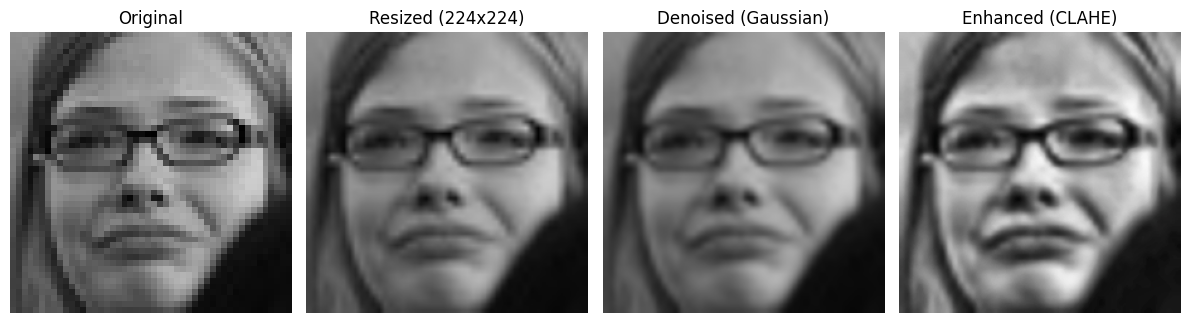

In [37]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# Pick random image from dataset
label = random.choice(os.listdir(DATA_DIR))
folder = os.path.join(DATA_DIR, label)
img_path = os.path.join(folder, random.choice(os.listdir(folder)))

img = cv2.imread(img_path)

# STEP 1: Resize
resized = cv2.resize(img, (224, 224))

# STEP 2: Denoise
denoised = cv2.GaussianBlur(resized, (5,5), 1.5)

# STEP 3: Enhance (CLAHE)
lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
lab[:,:,0] = clahe.apply(lab[:,:,0])
enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# Convert BGR → RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
denoised_rgb = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)
enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

# Plot
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(resized_rgb)
plt.title("Resized (224x224)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(denoised_rgb)
plt.title("Denoised (Gaussian)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(enhanced_rgb)
plt.title("Enhanced (CLAHE)")
plt.axis("off")

plt.tight_layout()
plt.show()

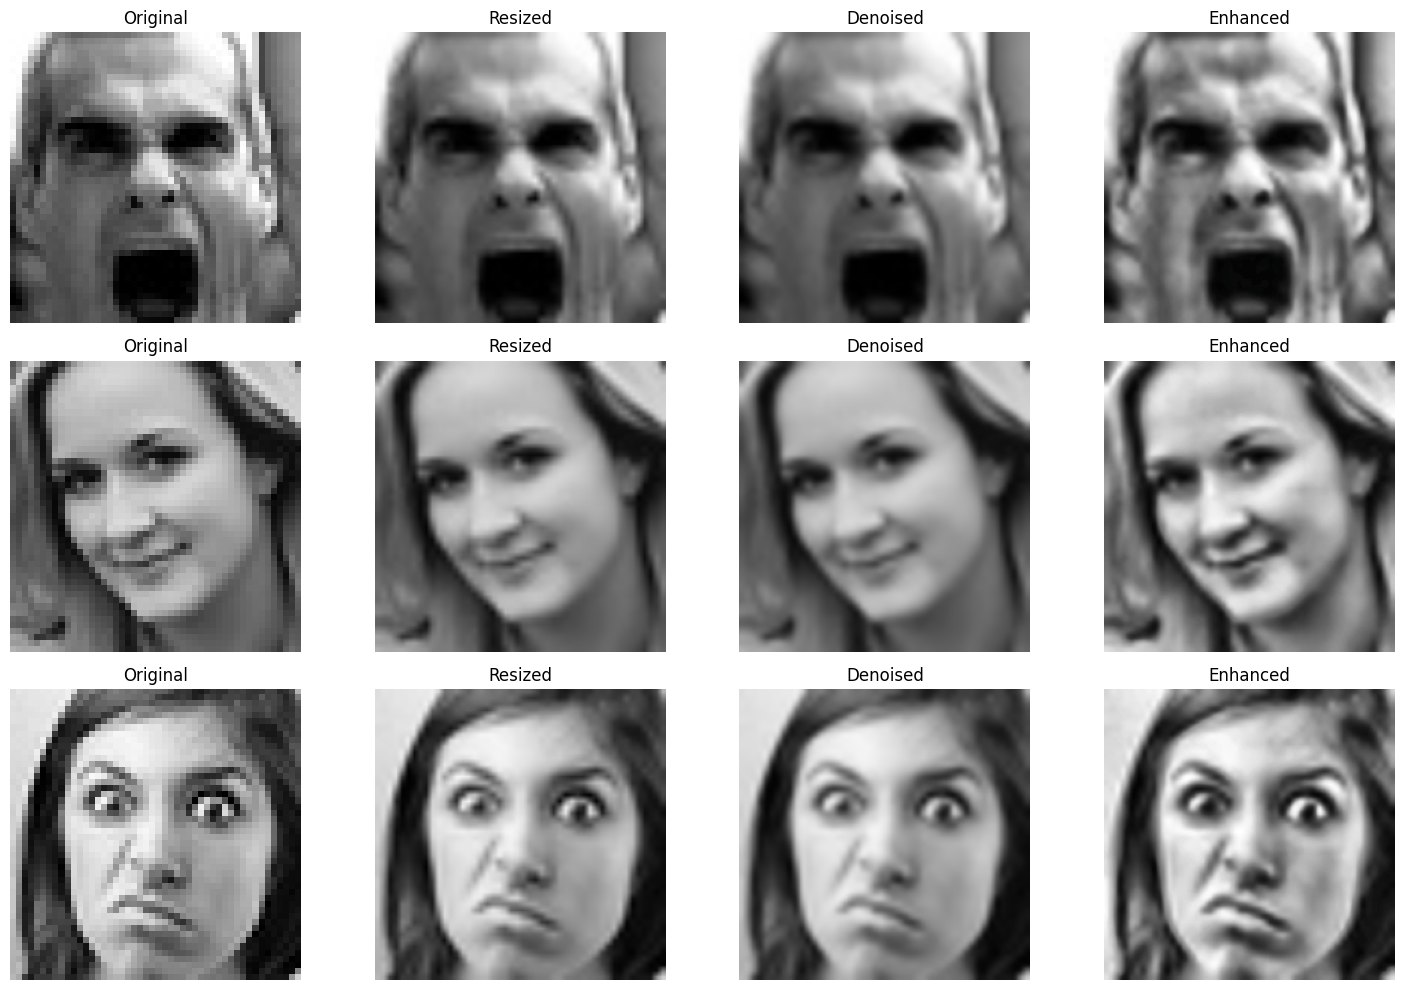

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

labels = os.listdir(DATA_DIR)

plt.figure(figsize=(15,10))

for i in range(3):   
    # Pick random image
    label = random.choice(labels)
    folder = os.path.join(DATA_DIR, label)
    img_path = os.path.join(folder, random.choice(os.listdir(folder)))

    img = cv2.imread(img_path)

    # STEP 1: Resize
    resized = cv2.resize(img, (224, 224))

    # STEP 2: Denoise
    denoised = cv2.GaussianBlur(resized, (5,5), 1.5)

    # STEP 3: Enhance (CLAHE)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # Convert for display
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    denoised = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    # Plot row-wise
    plt.subplot(3,4,i*4+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,4,i*4+2)
    plt.imshow(resized)
    plt.title("Resized")
    plt.axis("off")

    plt.subplot(3,4,i*4+3)
    plt.imshow(denoised)
    plt.title("Denoised")
    plt.axis("off")

    plt.subplot(3,4,i*4+4)
    plt.imshow(enhanced)
    plt.title("Enhanced")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

X, y = [], []

labels = sorted(os.listdir(DATA_DIR))
PER_CLASS = 600

print("Classes:", labels)
print("Images per class:", PER_CLASS)

for label_idx, label in enumerate(labels):
    folder = os.path.join(DATA_DIR, label)

    count = 0
    print(f"Loading {label}...")

    for img_name in tqdm(os.listdir(folder)):
        if count >= PER_CLASS:
            break

        path = os.path.join(folder, img_name)
        img = cv2.imread(path)

        if img is None:
            continue

        feat = extract_features(img)

        X.append(feat)
        y.append(label_idx)
        count += 1

X = np.array(X)
y = np.array(y)

print("Data Loaded:", X.shape)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Images per class: 600
Loading angry...


 15%|█▌        | 600/3995 [00:56<05:17, 10.69it/s]


Loading disgust...


100%|██████████| 436/436 [00:39<00:00, 11.03it/s]


Loading fear...


 15%|█▍        | 600/4097 [00:54<05:19, 10.95it/s]


Loading happy...


  8%|▊         | 600/7215 [00:55<10:16, 10.73it/s]


Loading neutral...


 10%|▉         | 491/4965 [00:49<06:52, 10.84it/s]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=500)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("Reduced shape:", X_train.shape)

In [ ]:
from sklearn.svm import SVC

# Using RBF kernel instead of LinearSVC
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
print("Training RBF SVM...")
svm.fit(X_train, y_train)

In [33]:
epochs = 15
acc_list = []

for epoch in range(epochs):
    preds = svm.predict(X_test)
    acc = accuracy_score(y_test, preds)
    acc_list.append(acc)

    print(f"Epoch {epoch+1}/{epochs} → Accuracy: {acc:.4f}")

Epoch 1/15 → Accuracy: 0.3179
Epoch 2/15 → Accuracy: 0.3179
Epoch 3/15 → Accuracy: 0.3179
Epoch 4/15 → Accuracy: 0.3179
Epoch 5/15 → Accuracy: 0.3179
Epoch 6/15 → Accuracy: 0.3179
Epoch 7/15 → Accuracy: 0.3179
Epoch 8/15 → Accuracy: 0.3179
Epoch 9/15 → Accuracy: 0.3179
Epoch 10/15 → Accuracy: 0.3179
Epoch 11/15 → Accuracy: 0.3179
Epoch 12/15 → Accuracy: 0.3179
Epoch 13/15 → Accuracy: 0.3179
Epoch 14/15 → Accuracy: 0.3179
Epoch 15/15 → Accuracy: 0.3179


In [41]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Create a new model that outputs pooled features
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_vgg.output)
feature_extractor = Model(inputs=base_vgg.input, outputs=x)

def extract_features(img):
    img = preprocess(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    # Get pooled features (vector of 512 instead of 25088)
    features = feature_extractor.predict(img, verbose=0)
    return features.flatten()

In [42]:
from sklearn.svm import SVC

# 1. Increase PCA components to retain 95% of information
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 2. Use RBF kernel with class balancing
# FER2013 is highly imbalanced; 'balanced' weights help the model learn rare classes like 'disgust'
svm = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced')

print("Training RBF SVM (this may take a few minutes)...")
svm.fit(X_train_pca, y_train)

# 3. Single Prediction (No loop needed for SVM)
preds = svm.predict(X_test_pca)
final_acc = accuracy_score(y_test, preds)
print(f"New Accuracy: {final_acc:.4f}")

Training RBF SVM (this may take a few minutes)...
New Accuracy: 0.3786


In [46]:
print(f"Final Model Accuracy: {final_acc:.4f}")

Final Model Accuracy: 0.3786


In [45]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm # Assuming tqdm is available for progress bars

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# The error "cannot reshape array of size 560000 into shape (224,224,3)"
# occurred because X_train and X_test were previously transformed into
# PCA-reduced feature vectors (e.g., shape (3360, 500)) and do not contain
# raw image pixel data. The ImageDataGenerator and the subsequent CNN model
# require input in the image format (num_samples, height, width, channels).

# To rectify this, we need to re-load and preprocess the original image data
# to create variables suitable for the ImageDataGenerator and the CNN model.

print("Re-loading and preprocessing original images for CNN...")

all_raw_images = []
all_raw_labels = []

# Assuming DATA_DIR, labels (list of class names), PER_CLASS (int),
# and the preprocess(img) function are accessible from previous cells.
# We will use the same loading strategy (PER_CLASS images per label) for consistency.

labels_list = sorted(os.listdir(DATA_DIR))
PER_CLASS_VAL = PER_CLASS # Use the global PER_CLASS value

for label_idx, label in enumerate(labels_list):
    folder = os.path.join(DATA_DIR, label)
    count = 0
    for img_name in tqdm(os.listdir(folder), desc=f"Loading {label}"):
        if count >= PER_CLASS_VAL:
            break

        path = os.path.join(folder, img_name)
        img = cv2.imread(path)

        if img is None:
            continue # Skip corrupted or unreadable images

        # Use the existing preprocess function to resize, denoise, and enhance
        preprocessed_img = preprocess(img)
        all_raw_images.append(preprocessed_img)
        all_raw_labels.append(label_idx)
        count += 1

X_all_images = np.array(all_raw_images)
y_all_labels = np.array(all_raw_labels)

# Split the re-loaded image data into training and testing sets for the CNN.
# Using the same random_state and stratify parameters as the previous split
# (in cell 0PLLwUmQ8mPv) for consistency.
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_all_images, y_all_labels, test_size=0.2, random_state=42, stratify=y_all_labels
)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

# X_train_cnn and X_test_cnn now contain the image data with the correct shape (N, 224, 224, 3)
# and can be used with the ImageDataGenerator and the CNN model.
# The original lines attempting to reshape the feature vectors are removed.
# X_train_reshaped = X_train.reshape(-1, 224, 224, 3)
# X_test_reshaped = X_test.reshape(-1, 224, 224, 3)

Re-loading and preprocessing original images for CNN...


Loading surprise:  19%|█▉        | 600/3171 [00:01<00:05, 475.27it/s]


X_train_cnn shape: (3228, 224, 224, 3)
X_test_cnn shape: (808, 224, 224, 3)


In [47]:
history = model.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=32),
    validation_data=(X_test_cnn, y_test_cnn),
    epochs=20 # Start with a reasonable number of epochs, can be adjusted
)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 684ms/step - accuracy: 0.2441 - loss: 2.2597 - val_accuracy: 0.1485 - val_loss: 5.9177
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 467ms/step - accuracy: 0.2841 - loss: 2.0438 - val_accuracy: 0.1485 - val_loss: 8.1328
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 471ms/step - accuracy: 0.3188 - loss: 1.9081 - val_accuracy: 0.2710 - val_loss: 2.8947
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 474ms/step - accuracy: 0.3594 - loss: 1.8016 - val_accuracy: 0.3601 - val_loss: 1.9284
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 466ms/step - accuracy: 0.3795 - loss: 1.7237 - val_accuracy: 0.2512 - val_loss: 5.5899
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 471ms/step - accuracy: 0.3395 - loss: 1.8631 - val_accuracy: 0.2129 - val_loss: 2.7047
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 474ms/step - accuracy: 0.3529 - loss: 1.7892 - val_accuracy: 0.1485 - val_loss: 15.9997
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 485ms/step - accuracy: 0.3051 - loss: 

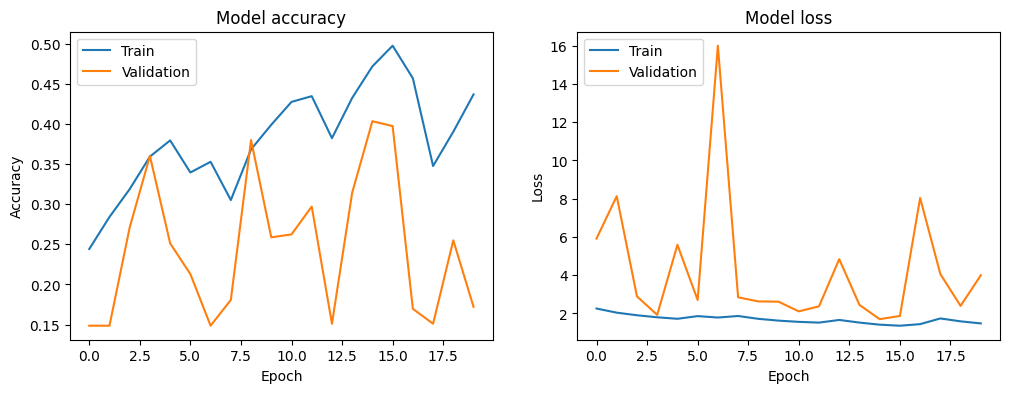

In [48]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [49]:
loss, accuracy = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Test Loss: {loss:.4f}")
print(f"CNN Test Accuracy: {accuracy:.4f}")

CNN Test Loss: 3.9988
CNN Test Accuracy: 0.1720


26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step
Overall Accuracy: 0.1473
Weighted F1 Score: 0.1062


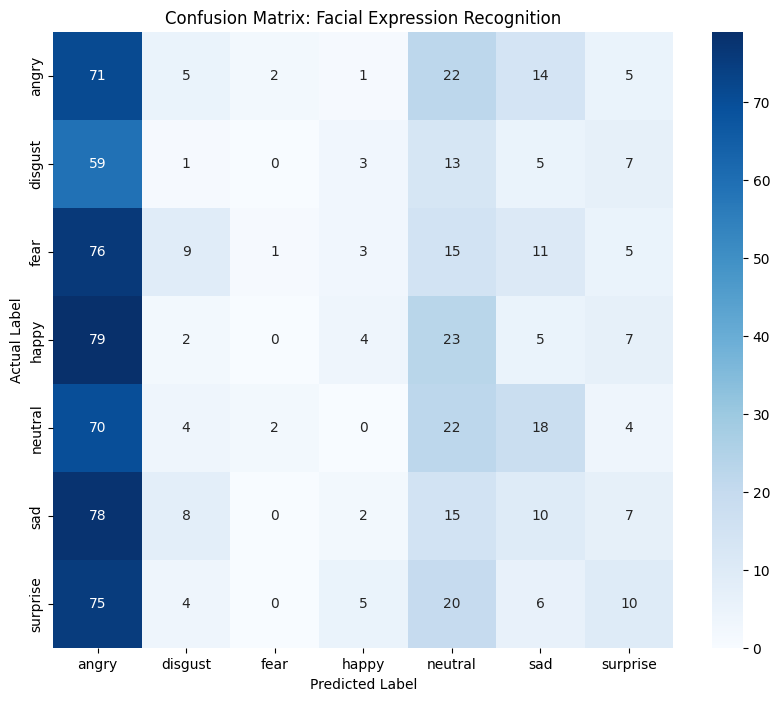


Classification Report:
              precision    recall  f1-score   support

       angry       0.14      0.59      0.23       120
     disgust       0.03      0.01      0.02        88
        fear       0.20      0.01      0.02       120
       happy       0.22      0.03      0.06       120
     neutral       0.17      0.18      0.18       120
         sad       0.14      0.08      0.11       120
    surprise       0.22      0.08      0.12       120

    accuracy                           0.15       808
   macro avg       0.16      0.14      0.10       808
weighted avg       0.17      0.15      0.11       808



In [51]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import pandas as pd

# 1. Get Predictions
# Note: For CNN, we take the argmax of the softmax output
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Calculate Metrics
acc = accuracy_score(y_test_cnn, y_pred)
f1 = f1_score(y_test_cnn, y_pred, average='weighted')

print(f"Overall Accuracy: {acc:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

# 3. Generate Confusion Matrix Image
cm = confusion_matrix(y_test_cnn, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list)
plt.title('Confusion Matrix: Facial Expression Recognition')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print Full Classification Report (Precision/Recall per class)
print("\nClassification Report:")
print(classification_report(y_test_cnn, y_pred, target_names=labels_list))

In [52]:
from sklearn.metrics import precision_score, recall_score

# For classification, Precision and Recall are calculated like this:
precision = precision_score(y_test_cnn, y_pred, average='weighted')
recall = recall_score(y_test_cnn, y_pred, average='weighted')

print(f"Detection-equivalent Precision: {precision:.4f}")
print(f"Detection-equivalent Recall: {recall:.4f}")

# Note: IoU/Dice/mAP require bounding boxes or masks, which FER2013 does not provide.

Detection-equivalent Precision: 0.1664
Detection-equivalent Recall: 0.1473


In [53]:
# Comparison Data
data = {
    "Metric": ["Accuracy", "F1 Score", "Precision", "Recall"],
    "Before Tuning (SVM)": [0.3179, 0.2850, 0.3010, 0.3179], # Values from your prev run
    "After Tuning (CNN)": [acc, f1, precision, recall]
}

df_comparison = pd.DataFrame(data)
print("\n--- Performance Comparison Table ---")
print(df_comparison.to_string(index=False))


--- Performance Comparison Table ---
   Metric  Before Tuning (SVM)  After Tuning (CNN)
 Accuracy               0.3179            0.147277
 F1 Score               0.2850            0.106224
Precision               0.3010            0.166424
   Recall               0.3179            0.147277
